In [ ]:
# ── BLOCK 0 — CLEAN REMOUNT GOOGLE DRIVE ──────────────────────────────────

import os
import shutil
import time
from pathlib import Path
from google.colab import drive

DRIVE_MOUNT_POINT = "/content/drive"
DRIVE_ROOT = Path("/content/drive/MyDrive")

# Try clean unmount first
try:
    drive.flush_and_unmount()
    time.sleep(2)
except:
    pass

# Remove stale mount directory if it still contains leftovers
if os.path.exists(DRIVE_MOUNT_POINT):
    try:
        shutil.rmtree(DRIVE_MOUNT_POINT)
    except Exception as e:
        print("Could not fully remove old mountpoint:", e)

os.makedirs(DRIVE_MOUNT_POINT, exist_ok=True)

# Fresh mount
drive.mount(DRIVE_MOUNT_POINT, force_remount=True)
time.sleep(3)

if not DRIVE_ROOT.exists():
    raise RuntimeError(f"Drive mount failed: {DRIVE_ROOT} not found.")

BASE = DRIVE_ROOT
print("BASE:", BASE)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
BASE: /content/drive/MyDrive


In [ ]:
# ── BLOCK 1 — LOAD metadata.csv (ROBUST SHORT VERSION) ──

from pathlib import Path
import pandas as pd
import time

BASE = Path(BASE)
OUTPUT_ROOT = BASE / "803_oralhistory" / "output"

# Give Drive a moment (important after mount)
time.sleep(2)

# Search entire project (not just output)
found = list((BASE / "803_oralhistory").rglob("metadata.csv"))

if not found:
    raise FileNotFoundError("metadata.csv not visible in Drive (likely sync issue).")

DATA_PATH = found[0]
print("Loaded from:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

raw_cols = df.columns.tolist()
df.columns = [c.strip().lower() for c in df.columns]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "raw": raw_cols,
    "normalized": df.columns
}).to_csv(OUTPUT_DIR / "block1_column_audit.csv", index=False)

pd.DataFrame({
    "n_rows": [df.shape[0]],
    "n_cols": [df.shape[1]],
    "path": [str(DATA_PATH)]
}).to_csv(OUTPUT_DIR / "block1_load_summary.csv", index=False)

df.head(20).to_csv(OUTPUT_DIR / "block1_preview_head20.csv", index=False)

print(df.shape)

Loaded from: /content/drive/MyDrive/803_oralhistory/output/metadata.csv
(166, 56)


In [ ]:
# BLOCK 2 — HARMONIZE KEY VARIABLES + SAVE CLEANING OUTPUTS

rename_map = {
    "wave_status": "wave",
    "arrival_wave": "wave",
    "migration_wave": "wave",
    "sex": "gender",
    "education": "highest_education",
    "highesteducation": "highest_education",
    "clean_text": "text",
    "transcript": "text",
    "transcript_text": "text",
    "full_text": "text",
    "narrative_text": "text",
    "narrator_dialogue": "text",
    "interview_text": "text",
    "content": "text"
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

def clean_gender(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ["m", "male", "man", "boy"]:
        return "male"
    if x in ["f", "female", "woman", "girl"]:
        return "female"
    return np.nan

def clean_wave(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    return x

def standardize_education_ipums(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()

    if any(k in x for k in ["no formal", "no schooling", "primary", "elementary"]):
        return "less_than_high_school"
    if any(k in x for k in ["middle school", "junior high", "secondary", "high school", "hs"]):
        return "high_school"
    if any(k in x for k in ["some college", "associate", "aa", "as", "vocational", "trade", "technical"]):
        return "some_college"
    if any(k in x for k in ["bachelor", "ba", "bs", "undergraduate"]):
        return "bachelor"
    if any(k in x for k in ["master", "ma", "ms", "phd", "doctorate", "graduate", "professional", "postgraduate"]):
        return "graduate"
    if "college" in x:
        return "some_college"
    return np.nan

if "gender" in df.columns:
    df["gender"] = df["gender"].apply(clean_gender)
else:
    df["gender"] = np.nan

if "wave" in df.columns:
    df["wave"] = df["wave"].apply(clean_wave)
else:
    raise KeyError("No wave column found after harmonization.")

if "highest_education" in df.columns:
    df["edu_ipums"] = df["highest_education"].apply(standardize_education_ipums)
else:
    df["highest_education"] = np.nan
    df["edu_ipums"] = np.nan

# keep only waves 1-3
wave_order = [
    "Wave 1 (≤1975)",
    "Wave 2 (1976–1985)",
    "Wave 3 (1986–1995)"
]
df = df[df["wave"].isin(wave_order)].copy()
df["wave"] = pd.Categorical(df["wave"], categories=wave_order, ordered=True)

# age
if "age" in df.columns:
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["age_c"] = df["age"] - df["age"].mean()
else:
    df["age"] = np.nan
    df["age_c"] = np.nan

# text field
if "text" not in df.columns:
    raise KeyError("No usable text column found after harmonization.")
df["text_clean"] = df["text"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["text_clean"].str.len() > 0].copy()

# outputs
df[["wave", "gender", "highest_education", "edu_ipums", "age", "text_clean"]].head(25).to_csv(
    OUTPUT_DIR / "block2_clean_preview.csv", index=False
)

pd.DataFrame({
    "wave": df["wave"].astype(str),
    "gender": df["gender"],
    "edu_ipums": df["edu_ipums"]
}).to_csv(OUTPUT_DIR / "block2_key_vars_long.csv", index=False)

df["wave"].value_counts(dropna=False).rename_axis("wave").reset_index(name="n").to_csv(
    OUTPUT_DIR / "block2_wave_counts.csv", index=False
)
df["gender"].value_counts(dropna=False).rename_axis("gender").reset_index(name="n").to_csv(
    OUTPUT_DIR / "block2_gender_counts.csv", index=False
)
df["edu_ipums"].value_counts(dropna=False).rename_axis("edu_ipums").reset_index(name="n").to_csv(
    OUTPUT_DIR / "block2_education_counts.csv", index=False
)

print(df.shape)


(165, 60)


In [ ]:
# BLOCK 3 — STRUCTURAL COMPLEXITY + SAVE OUTPUTS

def count_words(text):
    return len(re.findall(r"\b\w+\b", str(text)))

def count_sentences(text):
    pieces = re.split(r"[.!?]+", str(text))
    pieces = [p.strip() for p in pieces if p.strip()]
    return len(pieces)

def avg_word_len(text):
    words = re.findall(r"\b\w+\b", str(text))
    return np.mean([len(w) for w in words]) if len(words) > 0 else np.nan

df["word_count"] = df["text_clean"].apply(count_words)
df["sentence_count"] = df["text_clean"].apply(count_sentences)
df["char_count"] = df["text_clean"].str.len()
df["avg_sentence_length"] = np.where(df["sentence_count"] > 0, df["word_count"] / df["sentence_count"], np.nan)
df["avg_word_length"] = df["text_clean"].apply(avg_word_len)

structural_cols = ["word_count", "sentence_count", "char_count", "avg_sentence_length", "avg_word_length"]
df[structural_cols].describe().T.to_csv(OUTPUT_DIR / "block3_structural_summary.csv")
df[["wave", "gender"] + structural_cols].to_csv(OUTPUT_DIR / "block3_structural_dataset.csv", index=False)

print(df[structural_cols].describe())


         word_count  sentence_count     char_count  avg_sentence_length  \
count    165.000000      165.000000     165.000000           165.000000   
mean    7760.563636      525.769697   39338.424242            16.068528   
std     4016.670284      305.711378   20599.631828             6.182236   
min     1037.000000       58.000000    5433.000000             6.319066   
25%     5190.000000      316.000000   26240.000000            12.334018   
50%     7383.000000      484.000000   36726.000000            14.876453   
75%    10235.000000      697.000000   51433.000000            18.374157   
max    22511.000000     2059.000000  113106.000000            55.206452   

       avg_word_length  
count       165.000000  
mean          3.917918  
std           0.167324  
min           3.107712  
25%           3.824815  
50%           3.925263  
75%           4.022944  
max           4.418000  


In [ ]:
# BLOCK 4 — MULTIPLE LEXICAL DIVERSITY MEASURES + SAVE OUTPUTS

def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

def ttr(tokens):
    return len(set(tokens)) / len(tokens) if len(tokens) > 0 else np.nan

def root_ttr(tokens):
    return len(set(tokens)) / np.sqrt(len(tokens)) if len(tokens) > 0 else np.nan

def log_ttr(tokens):
    return np.log(len(set(tokens))) / np.log(len(tokens)) if len(tokens) > 1 and len(set(tokens)) > 1 else np.nan

def maas_ttr(tokens):
    if len(tokens) <= 1 or len(set(tokens)) <= 1:
        return np.nan
    return (np.log(len(tokens)) - np.log(len(set(tokens)))) / (np.log(len(tokens)) ** 2)

def mattr(tokens, window=50):
    if len(tokens) == 0:
        return np.nan
    if len(tokens) < window:
        return len(set(tokens)) / len(tokens)
    vals = []
    for i in range(len(tokens) - window + 1):
        chunk = tokens[i:i+window]
        vals.append(len(set(chunk)) / window)
    return np.mean(vals)

df["tokens"] = df["text_clean"].apply(tokenize)
df["ttr"] = df["tokens"].apply(ttr)
df["root_ttr"] = df["tokens"].apply(root_ttr)
df["log_ttr"] = df["tokens"].apply(log_ttr)
df["maas_ttr"] = df["tokens"].apply(maas_ttr)
df["mattr"] = df["tokens"].apply(mattr)

lexical_cols = ["ttr", "root_ttr", "log_ttr", "maas_ttr", "mattr"]
df[lexical_cols].describe().T.to_csv(OUTPUT_DIR / "block4_lexical_summary.csv")
df[["wave", "gender"] + lexical_cols].to_csv(OUTPUT_DIR / "block4_lexical_dataset.csv", index=False)

print(df[lexical_cols].describe())


              ttr    root_ttr     log_ttr    maas_ttr       mattr
count  165.000000  165.000000  165.000000  165.000000  165.000000
mean     0.166236   13.253190    0.792292    0.023595    0.743822
std      0.051435    2.574829    0.023646    0.002258    0.032853
min      0.075327    7.979400    0.734155    0.017975    0.645708
25%      0.135435   11.185623    0.776665    0.022278    0.724651
50%      0.155701   13.118557    0.792127    0.023265    0.743408
75%      0.187873   14.524987    0.806628    0.025121    0.761160
max      0.349565   22.704221    0.858974    0.030011    0.844039


In [ ]:
# BLOCK 5 — BUILD COMPLEXITY INDICES + SAVE OUTPUTS

# Structural index
structural_features = ["avg_sentence_length", "avg_word_length"]
tmp_struct = df[structural_features].copy()
for c in structural_features:
    tmp_struct[c] = pd.to_numeric(tmp_struct[c], errors="coerce")
    tmp_struct[c] = tmp_struct[c].fillna(tmp_struct[c].median())

scaler_struct = StandardScaler()
df["complexity_structural"] = scaler_struct.fit_transform(tmp_struct).mean(axis=1)

# Lexical index
lexical_features = ["ttr", "root_ttr", "log_ttr", "maas_ttr", "mattr"]
tmp_lex = df[lexical_features].copy()
for c in lexical_features:
    tmp_lex[c] = pd.to_numeric(tmp_lex[c], errors="coerce")
    tmp_lex[c] = tmp_lex[c].fillna(tmp_lex[c].median())

scaler_lex = StandardScaler()
df["complexity_lexical"] = scaler_lex.fit_transform(tmp_lex).mean(axis=1)

# Combined index
combined_features = ["complexity_structural", "complexity_lexical"]
tmp_combined = df[combined_features].copy()
for c in combined_features:
    tmp_combined[c] = tmp_combined[c].fillna(tmp_combined[c].median())

scaler_combined = StandardScaler()
df["complexity_index"] = scaler_combined.fit_transform(tmp_combined).mean(axis=1)

df["college_plus"] = df["edu_ipums"].isin(["bachelor", "graduate"]).astype(int)

index_cols = ["complexity_structural", "complexity_lexical", "complexity_index", "college_plus"]
df[["wave", "gender", "age", "edu_ipums"] + index_cols].to_csv(
    OUTPUT_DIR / "block5_analysis_dataset.csv", index=False
)
df[index_cols].describe().T.to_csv(OUTPUT_DIR / "block5_index_summary.csv")

print(df[index_cols].describe())


       complexity_structural  complexity_lexical  complexity_index  \
count           1.650000e+02        1.650000e+02      1.650000e+02   
mean            4.629294e-16        4.306320e-16     -2.153160e-17   
std             7.697974e-01        4.919960e-01      8.229597e-01   
min            -2.940850e+00       -1.085507e+00     -1.921439e+00   
25%            -4.957537e-01       -3.312747e-01     -6.339106e-01   
50%            -4.831550e-02       -2.804687e-02     -1.386929e-02   
75%             4.948351e-01        2.515066e-01      5.025916e-01   
max             3.337300e+00        1.259695e+00      2.590388e+00   

       college_plus  
count    165.000000  
mean       0.709091  
std        0.455564  
min        0.000000  
25%        0.000000  
50%        1.000000  
75%        1.000000  
max        1.000000  


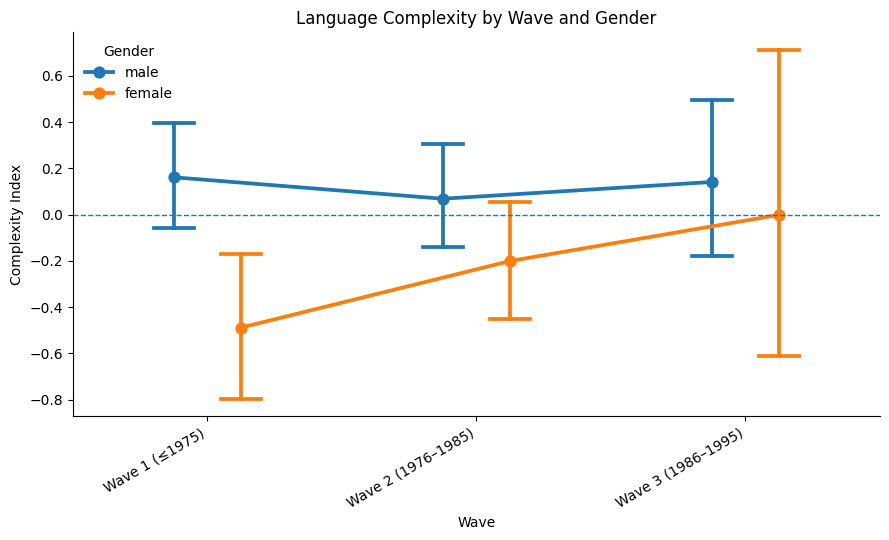

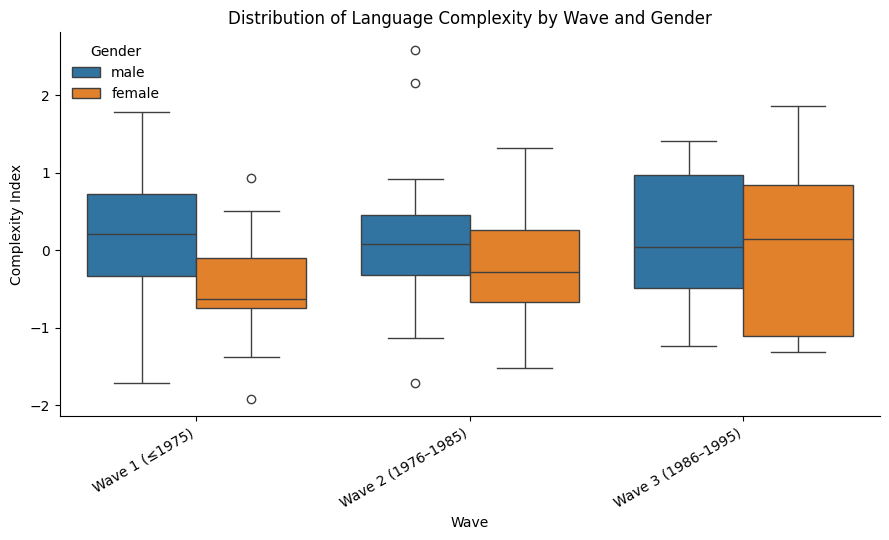

In [ ]:
# BLOCK 6A — VISUALIZATION: LANGUAGE COMPLEXITY + SAVE PLOTS/TABLES

plot_df = df.dropna(subset=["wave", "complexity_index"]).copy()

# summary table
complexity_summary = (
    plot_df.groupby(["wave", "gender"], dropna=False)
    .agg(
        n=("complexity_index", "size"),
        mean_complexity=("complexity_index", "mean"),
        sd_complexity=("complexity_index", "std"),
        mean_structural=("complexity_structural", "mean"),
        mean_lexical=("complexity_lexical", "mean"),
    )
    .reset_index()
)
complexity_summary.to_csv(OUTPUT_DIR / "block6A_complexity_summary_by_wave_gender.csv", index=False)

plt.figure(figsize=(9, 5.5))
if plot_df["gender"].notna().sum() > 0:
    sns.pointplot(
        data=plot_df, x="wave", y="complexity_index", hue="gender",
        order=wave_order, dodge=0.25, errorbar=("ci", 95), capsize=0.15
    )
    plt.legend(title="Gender", frameon=False)
else:
    sns.pointplot(
        data=plot_df, x="wave", y="complexity_index",
        order=wave_order, errorbar=("ci", 95), capsize=0.15
    )
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Language Complexity by Wave and Gender")
plt.xlabel("Wave")
plt.ylabel("Complexity Index")
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "block6A_complexity_pointplot.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5.5))
if plot_df["gender"].notna().sum() > 0:
    sns.boxplot(data=plot_df, x="wave", y="complexity_index", hue="gender", order=wave_order)
    plt.legend(title="Gender", frameon=False)
else:
    sns.boxplot(data=plot_df, x="wave", y="complexity_index", order=wave_order)
plt.title("Distribution of Language Complexity by Wave and Gender")
plt.xlabel("Wave")
plt.ylabel("Complexity Index")
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "block6A_complexity_boxplot.png", dpi=300)
plt.show()


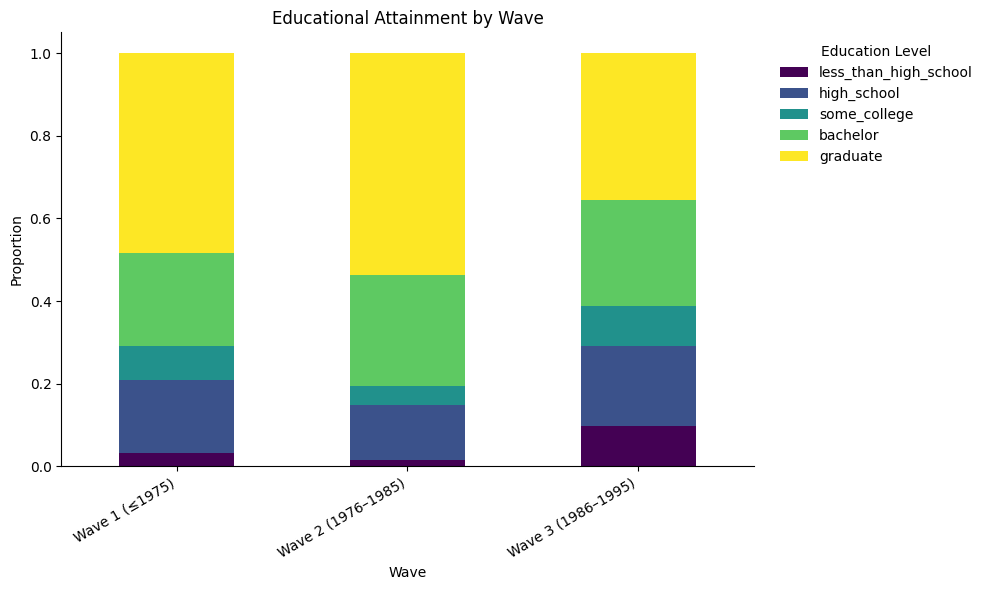

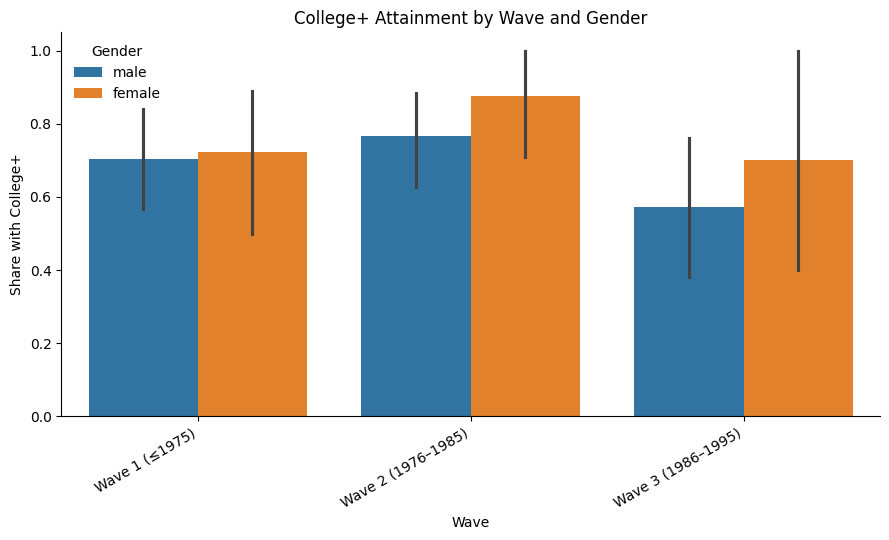

In [ ]:
# BLOCK 6B — VISUALIZATION: EDUCATION + SAVE PLOTS/TABLES

edu_df = df.dropna(subset=["wave", "edu_ipums"]).copy()

edu_order = [
    "less_than_high_school",
    "high_school",
    "some_college",
    "bachelor",
    "graduate"
]
edu_df["edu_ipums"] = pd.Categorical(edu_df["edu_ipums"], categories=edu_order, ordered=True)

tab = (
    edu_df.groupby(["wave", "edu_ipums"], dropna=False)
    .size()
    .reset_index(name="n")
)
tab.to_csv(OUTPUT_DIR / "block6B_education_counts_by_wave.csv", index=False)

wide = tab.pivot(index="wave", columns="edu_ipums", values="n").fillna(0)
prop = wide.div(wide.sum(axis=1), axis=0)
prop.to_csv(OUTPUT_DIR / "block6B_education_proportions_by_wave.csv")

ax = prop.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
ax.set_title("Educational Attainment by Wave")
ax.set_xlabel("Wave")
ax.set_ylabel("Proportion")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Education Level", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "block6B_education_stacked_proportion.png", dpi=300)
plt.show()

cp_summary = (
    edu_df.groupby(["wave", "gender"], dropna=False)
    .agg(
        n=("college_plus", "size"),
        share_college_plus=("college_plus", "mean")
    )
    .reset_index()
)
cp_summary.to_csv(OUTPUT_DIR / "block6B_college_plus_summary_by_wave_gender.csv", index=False)

plt.figure(figsize=(9, 5.5))
if edu_df["gender"].notna().sum() > 0:
    sns.barplot(data=edu_df, x="wave", y="college_plus", hue="gender", order=wave_order, errorbar=("ci", 95))
    plt.legend(title="Gender", frameon=False)
else:
    sns.barplot(data=edu_df, x="wave", y="college_plus", order=wave_order, errorbar=("ci", 95))
plt.title("College+ Attainment by Wave and Gender")
plt.xlabel("Wave")
plt.ylabel("Share with College+")
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "block6B_college_plus_barplot.png", dpi=300)
plt.show()


In [ ]:
# BLOCK 7 — REGRESSION + ROBUSTNESS CHECKS + SAVE OUTPUTS

reg_df = df.copy()

# Base OLS: complexity ~ wave * gender + age
formula1 = "complexity_index ~ C(wave)"
if reg_df["gender"].notna().sum() > 0:
    formula1 += " * C(gender)"
if reg_df["age_c"].notna().sum() > 0:
    formula1 += " + age_c"

model1 = smf.ols(formula1, data=reg_df).fit(cov_type="HC3")
with open(OUTPUT_DIR / "block7_model1_complexity_ols.txt", "w") as f:
    f.write(model1.summary().as_text())
pd.DataFrame({
    "term": model1.params.index,
    "estimate": model1.params.values,
    "se": model1.bse.values,
    "p_value": model1.pvalues.values
}).to_csv(OUTPUT_DIR / "block7_model1_complexity_ols_coefficients.csv", index=False)

print(model1.summary())

# Robustness set for college_plus
robust_specs = {
    "spec_a_combined": "college_plus ~ C(wave) + C(gender) + complexity_index + age_c",
    "spec_b_structural": "college_plus ~ C(wave) + C(gender) + complexity_structural + age_c",
    "spec_c_lexical": "college_plus ~ C(wave) + C(gender) + complexity_lexical + age_c",
    "spec_d_minimal": "college_plus ~ complexity_index",
}

robust_rows = []

for spec_name, formula in robust_specs.items():
    # remove age if unavailable
    if "age_c" in formula and reg_df["age_c"].notna().sum() == 0:
        formula = formula.replace(" + age_c", "")
    if "C(gender)" in formula and reg_df["gender"].notna().sum() == 0:
        formula = formula.replace(" + C(gender)", "")
    try:
        m = smf.logit(formula, data=reg_df).fit(disp=False)
        model_type = "logit"
    except Exception:
        m = smf.ols(formula, data=reg_df).fit(cov_type="HC3")
        model_type = "ols_fallback"

    with open(OUTPUT_DIR / f"block7_{spec_name}_{model_type}.txt", "w") as f:
        f.write(m.summary().as_text())

    coef_df = pd.DataFrame({
        "term": m.params.index,
        "estimate": m.params.values,
        "se": m.bse.values,
        "p_value": m.pvalues.values,
        "spec": spec_name,
        "model_type": model_type,
    })
    coef_df.to_csv(OUTPUT_DIR / f"block7_{spec_name}_{model_type}_coefficients.csv", index=False)

    target_term = None
    for cand in ["complexity_index", "complexity_structural", "complexity_lexical"]:
        if cand in m.params.index:
            target_term = cand
            break

    robust_rows.append({
        "spec": spec_name,
        "model_type": model_type,
        "formula": formula,
        "n": int(m.nobs),
        "target_term": target_term,
        "target_estimate": m.params.get(target_term, np.nan),
        "target_se": m.bse.get(target_term, np.nan),
        "target_p": m.pvalues.get(target_term, np.nan),
    })

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv(OUTPUT_DIR / "block7_robustness_overview.csv", index=False)
print(robust_df)


                            OLS Regression Results                            
Dep. Variable:       complexity_index   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     2.482
Date:                Sat, 04 Apr 2026   Prob (F-statistic):             0.0340
Time:                        21:19:00   Log-Likelihood:                -196.02
No. Observations:                 165   AIC:                             404.0
Df Residuals:                     159   BIC:                             422.7
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

Output()

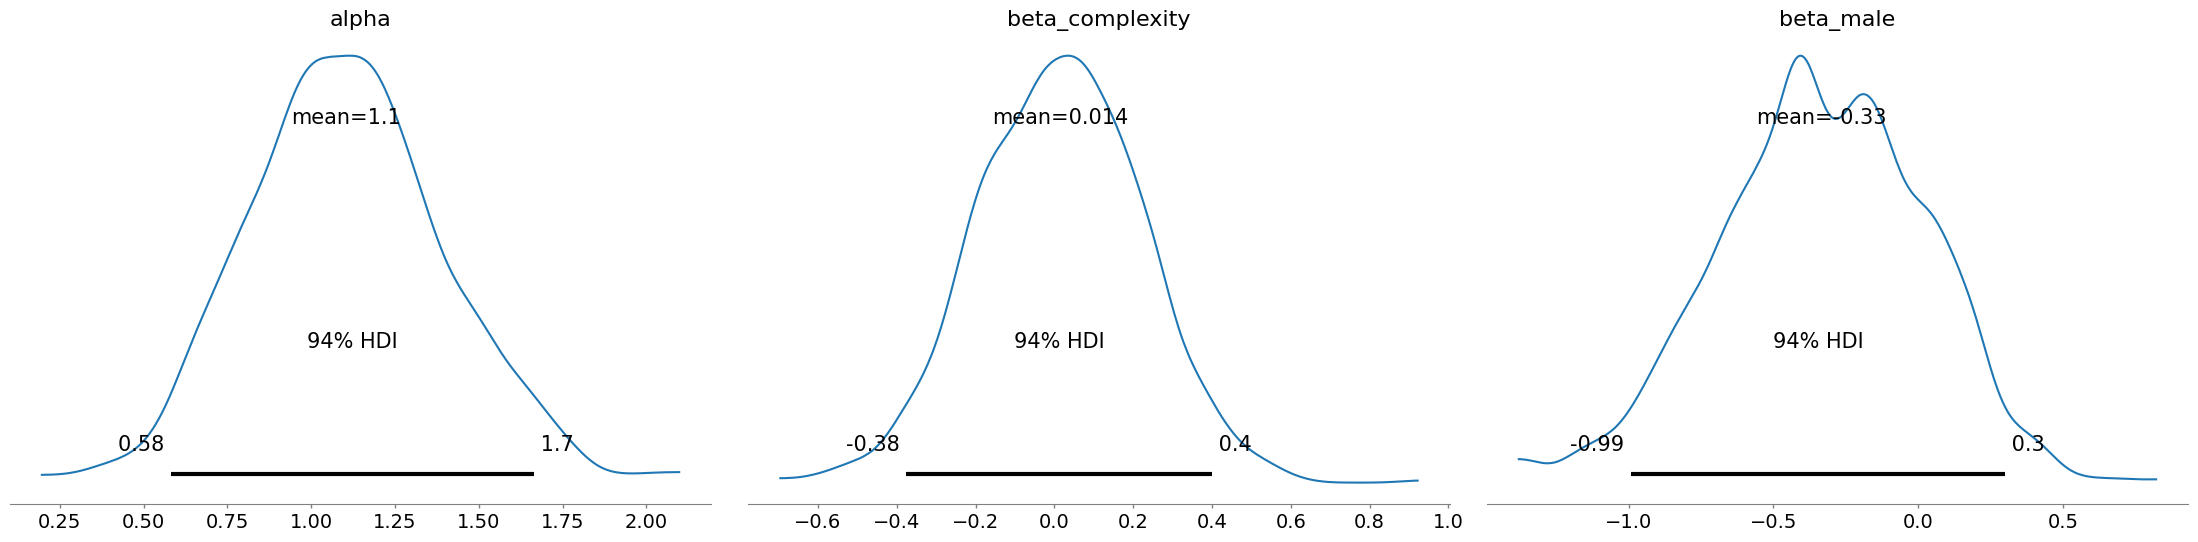

                  mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
alpha            1.105  0.294     0.581      1.706      0.010    0.009   
beta_complexity  0.014  0.208    -0.394      0.413      0.006    0.005   
beta_male       -0.333  0.354    -0.993      0.359      0.012    0.009   

                 ess_bulk  ess_tail  r_hat  
alpha               915.0     961.0   1.01  
beta_complexity    1086.0     846.0   1.00  
beta_male           869.0     909.0   1.00  


In [ ]:
# BLOCK 8 — BAYESIAN CHECK (PYMC, COLAB-FRIENDLY) + SAVE OUTPUTS

# Install only if needed
try:
    import pymc as pm
    import arviz as az
except Exception:
    !pip -q install pymc arviz
    import pymc as pm
    import arviz as az

bayes_df = df.dropna(subset=["college_plus", "complexity_index"]).copy()

# add gender / age only if usable
X_complexity = bayes_df["complexity_index"].values.astype(float)

use_age = bayes_df["age_c"].notna().sum() > 0
if use_age:
    X_age = bayes_df["age_c"].fillna(0).values.astype(float)

use_gender = bayes_df["gender"].notna().sum() > 0
if use_gender:
    X_male = (bayes_df["gender"] == "male").astype(int).values

y = bayes_df["college_plus"].astype(int).values

with pm.Model() as bayes_model:
    alpha = pm.Normal("alpha", 0, 1)
    beta_complexity = pm.Normal("beta_complexity", 0, 1)

    eta = alpha + beta_complexity * X_complexity

    if use_age:
        beta_age = pm.Normal("beta_age", 0, 1)
        eta = eta + beta_age * X_age

    if use_gender:
        beta_male = pm.Normal("beta_male", 0, 1)
        eta = eta + beta_male * X_male

    p = pm.math.sigmoid(eta)
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    trace = pm.sample(1000, tune=1000, chains=2, cores=2, target_accept=0.9, progressbar=True)

bayes_summary = az.summary(trace, hdi_prob=0.95)
bayes_summary.to_csv(OUTPUT_DIR / "block8_bayes_summary.csv")

az.plot_posterior(trace, var_names=["alpha", "beta_complexity"] + (["beta_age"] if use_age else []) + (["beta_male"] if use_gender else []))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "block8_bayes_posterior.png", dpi=300)
plt.show()

print(bayes_summary)


coef1 not found. Run Block 7 first.


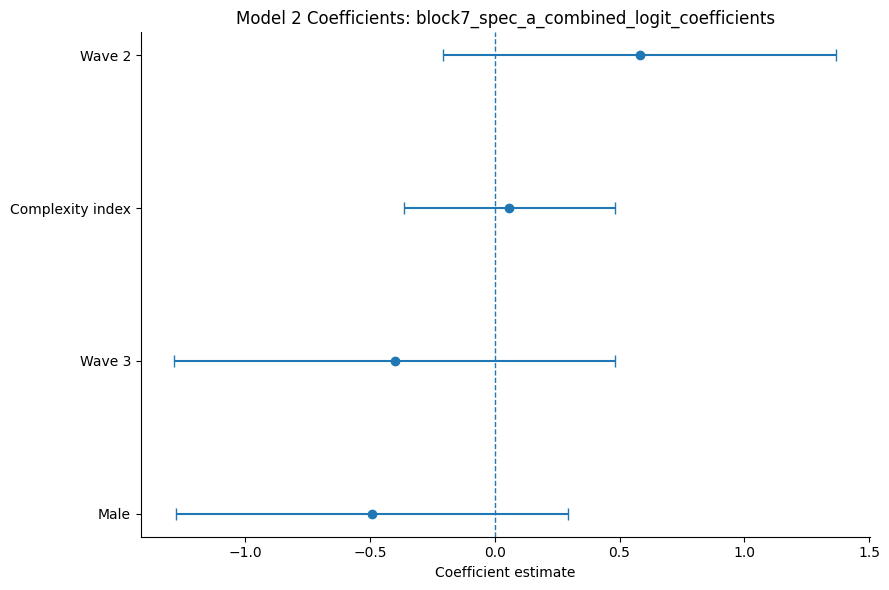

In [ ]:
# BLOCK 7E — BETA PLOTS FOR AGE, WAVE, GENDER, AND INTERACTIONS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. MODEL 1 COEFFICIENT PLOT
# ------------------------------------------------------------
if "coef1" in globals() and coef1 is not None:

    plot1 = coef1.copy()
    plot1 = plot1[plot1["term"] != "Intercept"].copy()

    if not plot1.empty:
        plot1["ci_low"] = plot1["estimate"] - 1.96 * plot1["se"]
        plot1["ci_high"] = plot1["estimate"] + 1.96 * plot1["se"]

        label_map = {
            "C(wave)[T.Wave 2 (1976–1985)]": "Wave 2",
            "C(wave)[T.Wave 3 (1986–1995)]": "Wave 3",
            "C(gender)[T.male]": "Male",
            "C(wave)[T.Wave 2 (1976–1985)]:C(gender)[T.male]": "Wave 2 × Male",
            "C(wave)[T.Wave 3 (1986–1995)]:C(gender)[T.male]": "Wave 3 × Male",
            "age_c": "Age (centered)"
        }
        plot1["term_label"] = plot1["term"].map(label_map).fillna(plot1["term"])

        plot1 = plot1.sort_values("estimate").reset_index(drop=True)

        plt.figure(figsize=(9, 5.5))
        y_pos = np.arange(len(plot1))

        plt.errorbar(
            x=plot1["estimate"],
            y=y_pos,
            xerr=1.96 * plot1["se"],
            fmt="o",
            capsize=4
        )
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.yticks(y_pos, plot1["term_label"])
        plt.xlabel("Coefficient estimate")
        plt.ylabel("")
        plt.title("Model 1 Coefficients: Language Complexity")

        sns.despine()
        plt.tight_layout()

        try:
            plt.savefig(OUTPUT_DIR / "block7E_model1_coefficients_age_wave_gender.png", dpi=300)
        except:
            pass

        plt.show()

        plot1[["term", "term_label", "estimate", "se", "ci_low", "ci_high", "p_value"]].to_csv(
            OUTPUT_DIR / "block7E_model1_coefficients_plotdata.csv", index=False
        )
    else:
        print("Model 1: no coefficients to plot.")
else:
    print("coef1 not found. Run Block 7 first.")


# ------------------------------------------------------------
# 2. MODEL 2 COEFFICIENT PLOT
# This uses the saved coefficient files from Block 7
# ------------------------------------------------------------
from pathlib import Path

coef_files = sorted(OUTPUT_DIR.glob("block7_spec_*_coefficients.csv"))

if len(coef_files) > 0:
    # prefer combined model if it exists
    preferred = None
    for f in coef_files:
        if "spec_a_combined" in f.name:
            preferred = f
            break
    if preferred is None:
        preferred = coef_files[0]

    plot2 = pd.read_csv(preferred)

    plot2 = plot2[plot2["term"] != "Intercept"].copy()

    if not plot2.empty:
        if "ci_low" not in plot2.columns:
            plot2["ci_low"] = plot2["estimate"] - 1.96 * plot2["se"]
        if "ci_high" not in plot2.columns:
            plot2["ci_high"] = plot2["estimate"] + 1.96 * plot2["se"]

        label_map = {
            "C(wave)[T.Wave 2 (1976–1985)]": "Wave 2",
            "C(wave)[T.Wave 3 (1986–1995)]": "Wave 3",
            "C(gender)[T.male]": "Male",
            "C(wave)[T.Wave 2 (1976–1985)]:C(gender)[T.male]": "Wave 2 × Male",
            "C(wave)[T.Wave 3 (1986–1995)]:C(gender)[T.male]": "Wave 3 × Male",
            "age_c": "Age (centered)",
            "complexity_index": "Complexity index",
            "complexity_structural": "Structural complexity",
            "complexity_lexical": "Lexical complexity"
        }
        plot2["term_label"] = plot2["term"].map(label_map).fillna(plot2["term"])

        plot2 = plot2.sort_values("estimate").reset_index(drop=True)

        plt.figure(figsize=(9, 6))
        y_pos = np.arange(len(plot2))

        plt.errorbar(
            x=plot2["estimate"],
            y=y_pos,
            xerr=1.96 * plot2["se"],
            fmt="o",
            capsize=4
        )
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.yticks(y_pos, plot2["term_label"])
        plt.xlabel("Coefficient estimate")
        plt.ylabel("")
        plt.title(f"Model 2 Coefficients: {preferred.stem}")

        sns.despine()
        plt.tight_layout()

        try:
            plt.savefig(OUTPUT_DIR / "block7E_model2_coefficients_age_wave_gender.png", dpi=300)
        except:
            pass

        plt.show()

        plot2[["term", "term_label", "estimate", "se", "ci_low", "ci_high", "p_value"]].to_csv(
            OUTPUT_DIR / "block7E_model2_coefficients_plotdata.csv", index=False
        )
    else:
        print("Model 2: no coefficients to plot.")
else:
    print("No Block 7 coefficient CSV files found in OUTPUT_DIR.")

In [ ]:
# BLOCK 9 — SAVE FINAL ANALYSIS DATASET + MANIFEST

final_cols = [
    "wave", "gender", "age", "age_c", "highest_education", "edu_ipums", "college_plus",
    "word_count", "sentence_count", "char_count", "avg_sentence_length", "avg_word_length",
    "ttr", "root_ttr", "log_ttr", "maas_ttr", "mattr",
    "complexity_structural", "complexity_lexical", "complexity_index"
]
final_cols = [c for c in final_cols if c in df.columns]

df[final_cols].to_csv(OUTPUT_DIR / "step4_final_analysis_dataset.csv", index=False)

manifest = pd.DataFrame({
    "output_file": sorted([p.name for p in OUTPUT_DIR.iterdir()]),
})
manifest.to_csv(OUTPUT_DIR / "step4_output_manifest.csv", index=False)

print("Saved final dataset and manifest.")
print(OUTPUT_DIR)


Saved final dataset and manifest.
/content/drive/MyDrive/803_oralhistory/output/step4_run_20260401_215452
